# Extraction using new algo
1. Use class UmapAlgo to calculate all start points
2. Extract from -3000 step to +2000 step around start point
3. Store in such a way so that you can separate partial an full later
4. Save this local order data

In [111]:
%reload_ext autoreload
%autoreload 2

from tes.data_ingestion import DataRead
from tes.algo_umap import UmapAlgo
from tes.algo_partial_full import AlgoParFull
from tes.analysis import AnalysisFunc
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from pathlib import Path
import glob

In [112]:
reader = DataRead()
analyse=AnalysisFunc()
algo = AlgoParFull()
algoumap=UmapAlgo()

#### To extract global order

In [ ]:
reader.data_read_bz2('raw/workstation/tes_peri_go.bz2').shape

In [ ]:
#reader.new_algo_ext(200,"raw/workstation/tes_peri_go.bz2","raw/workstation/tes_peri_lo.bz2")

In [ ]:
df_loc=reader.data_read_bz2("raw/workstation/tes_mob_lo.bz2")

In [ ]:
reader.ext_node_community(df_loc,0.5,"raw/workstation/tes_mob_nc.bz2")

In [ ]:
# check for already stored data
df_fn= reader.data_read_bz2("raw/workstation/tes_fn_go.bz2") 
#df_loc_fn = reader.data_read_bz2("raw/workstation/tes_fn_lo.bz2")

In [ ]:
df_peri = reader.data_read_bz2("raw/workstation/tes_peri_go.bz2")
#df_loc_peri = reader.data_read_bz2("raw/workstation/tes_peri_lo.bz2")

In [ ]:
df_peri_nc=reader.data_read_bz2("raw/workstation/tes_peri_nc.bz2")                                                                 

#### Visualize transition

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


NameError: name 'thresh_go' is not defined

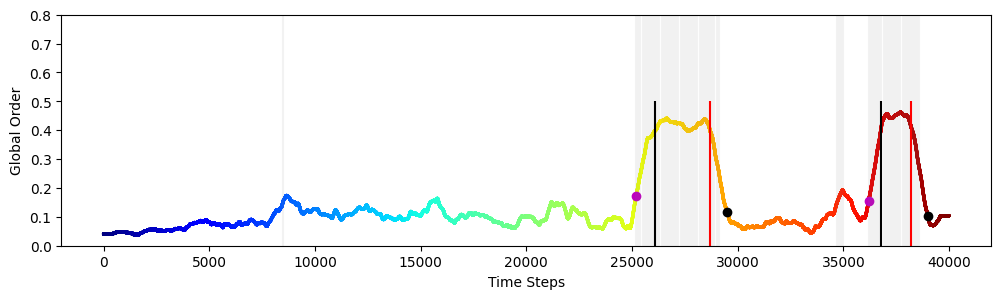

In [ ]:
n=6
# find start stop points
pts=algoumap.compute_parameters(df_fn[n])
algoumap.plot_transition(df_fn[n],pts['start_points'],pts['stop_points'])
plt.ylim(0,0.8)

# for i in comm_pts['start_comm']:
#     plt.vlines(i,0,0.5, color='k')
# for i in comm_pts['stop_comm']:
#     plt.vlines(i,0,0.5, color='r')


# for i, threshold in enumerate(thresh_go):
#     if i==0:
#         plt.hlines(threshold,0,40000, color='m')
#     elif i==1:
#         plt.hlines(threshold,0,40000, color='c')
#     elif i==2:
#         plt.hlines(threshold,0,40000, color='y')
#     else:
#         plt.hlines(threshold,0,40000, color='g')


#### Find points where 90% of global order is crossed in a transition
- If transition never falls down, take the last timestep

In [ ]:
def get_crossing_go(df, pts):
    """Get start and stop points where global order is 90%

    Args:
        df (dataframe): Global order dataframe of timesteps x iterations
        pts (dictionary): Start and Stop points of transition
        

    Returns:
        dictionary: keys are 'start_comm' and 'stop_comm' with respective lists of points
    """
    # Ensure stop points match start points
    if len(pts['start_points']) > len(pts['stop_points']):
        pts['stop_points'].append(len(df) - 1)

    _data = df.rolling(800, center=True).mean().ffill().bfill()
    start_comm=[]
    stop_comm=[]
    thresh_go=[]
    all_crossings = []
    for start, stop in zip(pts['start_points'], pts['stop_points']):
        #_data = df_fn[n].iloc[start:stop].rolling(800, center=True).mean().ffill().bfill()
        values = _data.iloc[start:stop].values
        window_values = values.copy()

        max_val = values.max()
        threshold = 0.90 * max_val
        thresh_go.append(threshold)
        above_threshold = window_values >= threshold

        # Detect transitions
        transitions = np.diff(above_threshold.astype(int))
        rising_edges = np.where(transitions == 1)[0]      # below → above
        falling_edges = np.where(transitions == -1)[0]     # above → below

        # Combine and sort all crossings
        #all_edges = np.sort(np.concatenate((rising_edges, falling_edges)))
        all_edges = np.concatenate((rising_edges, falling_edges))
        actual_indices = all_edges + start

        if len(actual_indices) > 0:
            all_crossings.extend(actual_indices)
            start_comm.append(actual_indices[0])
            # stop_comm.append(actual_indices[-1])
            if actual_indices[0]!=actual_indices[-1]:
                stop_comm.append(actual_indices[-1])
            elif stop==39999:
                # to take care of transitions which never fall back
                stop_comm.append(stop)
            else:
                # to take care of rolling window in the end cases
                print('this cell')
                stop_comm.append(stop+400)

            #print(f'Start {start} Stop {stop} Threshold {threshold}')
            #print(f'Crossing points (rising & falling): {actual_indices}')
        else:
            #print(f'No threshold crossing found between {start} and {stop}')
            closest_idx = np.argmin(np.abs(window_values - threshold))
            actual_idx = int(closest_idx) + start
            #print(f'Closest point to threshold at index: {actual_idx}')
            start_comm.append(start)
            stop_comm.append(stop)

    # print(f'\nTotal number of crossing points found: {len(all_crossings)}')
    # print(f' points {start_comm} ,{stop_comm}, {thresh_go}')
    
    return {'start_comm':start_comm,'stop_comm':stop_comm}

#### Using above function

In [ ]:
# find start stop points for transition
pts=algoumap.compute_parameters(df_fn[n])

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
# find start stop points where global order crosses 90%
comm_pts=get_crossing_go(df_fn[n], pts)

In [ ]:
comm_pts

{'start_comm': [26075, 36805], 'stop_comm': [28701, 38188]}

#### Get the binarized matrix
- columns arranged community wise

In [ ]:
def get_binairized_matrix(df,trans_start):
    """Gives binarized matrix in desired order. YOu can uncomment plt lines to visualise the matrix.

    Args:
        df (dataframe): node community dataframe only transition part (5000x426)
        trans_start (int): starting point of transition
    Returns:
        dataframe: Binarized dataframe with community ordering
    """
    des_order=reader.get_communities()['des_order']
    mc = analyse.compute_main_cluster(df)
    nc_array = df.values
    nc=nc_array.copy()
    #print(mc)

    binary_mask = np.isclose(nc, mc)
    bm_ordered = binary_mask.T[des_order]

    df_bm=pd.DataFrame(bm_ordered).T
    #trans_start=pts['start_points'][0]
    df_bm.index=list(range(trans_start-3000,trans_start+2000))
    # plt.imshow(df_bm.T, cmap='gray', interpolation='nearest', aspect = 'auto')
    # plt.colorbar()
    # plt.title('Binarised matrix with community ordering')
    return df_bm

#### Checking above function

In [ ]:
df_bm=get_binairized_matrix(df_fn_nc.loc[n].iloc[0:5000],pts['start_points'][1])

#### Get community percentage

In [ ]:


def get_community_percentage(start, stop, df_bm):
    """
    Calculates community-wise percentage for a given transition range.

    Args:
        start (int/float): starting timestep (e.g., 90% global order timestep)
        stop (int/float): ending timestep (e.g., below 90% global order timestep)
        df_bm (pd.DataFrame): binarised node-community dataframe (timesteps × nodes)
        
    """
    
    comm_count=reader.get_communities()['comm_val']
    comm_name=reader.get_communities()['name_seq']
    cum_count=np.cumsum(comm_count)

    # Define the time window (handle missing stop)
    if start not in df_bm.index:
        raise ValueError("Start index not found in dataframe")
    if stop in df_bm.index:
        df_slice = df_bm.loc[start:stop]
    else:
        df_slice = df_bm.loc[start:]
    
    results = []

    init = 0
    for count, name in zip(cum_count, comm_name):
        sub_array = df_slice.iloc[:, init:count].values
        tot=sub_array.size
        count_true=np.sum(sub_array)
        percentage=(count_true/tot)*100
        results.append({
            "community": name,
            "total": tot,
            "percentage": percentage
        })
        init = count
    df=pd.DataFrame(results)
    df=df.set_index('community')
    return df


#### Check community percentage

In [ ]:
df_gc=get_community_percentage( comm_pts['start_comm'][1], comm_pts['stop_comm'][1], df_bm)

In [ ]:
comm_pts['stop_comm'][1]

30100

In [ ]:
df_gc

,total,percentage
community,,
MO,43120,70.830241
VIS,38500,65.670130
ORB,26180,90.607334
HTh,33880,77.647580
OLF,27720,92.334055
HIPP,38500,61.818182
MID,53900,45.749536
HIND,66220,5.454545


In [ ]:
df_gc

,total,percentage
community,,
MO,15736,79.855109
VIS,14050,89.295374
ORB,9554,98.995185
HTh,12364,97.395665
OLF,10116,100.000000
HIPP,14050,84.768683
MID,19670,57.432639
HIND,24166,2.085575


#### Function which gives community participation for partial and full transitions

In [ ]:
itr=n
threshold=0.39874500541287045
pts=algoumap.compute_parameters(df_fn[itr])
cov=algo.compute_coverage(df_fn[itr], pts['start_points'], pts['stop_points'])
ind=algo.compute_num_trans(cov,threshold)

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
ind['part_ind']

[0]

In [ ]:
ind['count_trans']

2

In [ ]:
tran_itr 

[0, 1, 2, 5, 6, 7, 8, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20, 21, 22, 23, 24]

### Class to compute community percentage partially and completely

In [ ]:
class CommPercentages:
    def __init__(self):
        self.full_mo_tot=[]
        self.full_mo_per=[]
        self.full_vis_tot=[]
        self.full_vis_per=[]
        self.full_orb_tot=[]
        self.full_orb_per=[] 
        self.full_hth_tot=[]
        self.full_hth_per=[]
        self.full_olf_tot=[]
        self.full_olf_per=[]
        self.full_hipp_tot=[]
        self.full_hipp_per=[] 
        self.full_mid_tot=[]
        self.full_mid_per=[]
        self.full_hind_tot=[]
        self.full_hind_per=[]

        self.part_mo_tot=[]
        self.part_mo_per=[]
        self.part_vis_tot=[]
        self.part_vis_per=[]
        self.part_orb_tot=[]
        self.part_orb_per=[] 
        self.part_hth_tot=[]
        self.part_hth_per=[]
        self.part_olf_tot=[]
        self.part_olf_per=[]
        self.part_hipp_tot=[]
        self.part_hipp_per=[] 
        self.part_mid_tot=[]
        self.part_mid_per=[]
        self.part_hind_tot=[]
        self.part_hind_per=[]

    def store_full_data(self, df_gc):
        self.full_mo_tot.append(df_gc.loc['MO']['total'])
        self.full_mo_per.append(df_gc.loc['MO']['percentage'])

            
        self.full_vis_tot.append(df_gc.loc['VIS']['total'])
        self.full_vis_per.append(df_gc.loc['VIS']['percentage'])

                
        self.full_orb_tot.append(df_gc.loc['ORB']['total'])
        self.full_orb_per.append(df_gc.loc['ORB']['percentage'])


        self.full_hth_tot.append(df_gc.loc['HTh']['total'])
        self.full_hth_per.append(df_gc.loc['HTh']['percentage'])

        
        self.full_olf_tot.append(df_gc.loc['OLF']['total'])
        self.full_olf_per.append(df_gc.loc['OLF']['percentage'])
        print(f'full: {self.full_olf_per}')

        self.full_hipp_tot.append(df_gc.loc['HIPP']['total'])
        self.full_hipp_per.append(df_gc.loc['HIPP']['percentage'])


        self.full_mid_tot.append(df_gc.loc['MID']['total'])
        self.full_mid_per.append(df_gc.loc['MID']['percentage'])


        self.full_hind_tot.append(df_gc.loc['HIND']['total'])
        self.full_hind_per.append(df_gc.loc['HIND']['percentage'])

    def store_part_data(self, df_gc):
        self.part_mo_tot.append(df_gc.loc['MO']['total'])
        self.part_mo_per.append(df_gc.loc['MO']['percentage'])

            
        self.part_vis_tot.append(df_gc.loc['VIS']['total'])
        self.part_vis_per.append(df_gc.loc['VIS']['percentage'])

                
        self.part_orb_tot.append(df_gc.loc['ORB']['total'])
        self.part_orb_per.append(df_gc.loc['ORB']['percentage'])


        self.part_hth_tot.append(df_gc.loc['HTh']['total'])
        self.part_hth_per.append(df_gc.loc['HTh']['percentage'])

        
        self.part_olf_tot.append(df_gc.loc['OLF']['total'])
        self.part_olf_per.append(df_gc.loc['OLF']['percentage'])
        print(f'part: {self.part_olf_per}')


        self.part_hipp_tot.append(df_gc.loc['HIPP']['total'])
        self.part_hipp_per.append(df_gc.loc['HIPP']['percentage'])


        self.part_mid_tot.append(df_gc.loc['MID']['total'])
        self.part_mid_per.append(df_gc.loc['MID']['percentage'])


        self.part_hind_tot.append(df_gc.loc['HIND']['total'])
        self.part_hind_per.append(df_gc.loc['HIND']['percentage'])

    def weighted_avg_and_std(self, values, weights):
        # Convert to NumPy arrays to allow element-wise arithmetic
        values = np.array(values, dtype=float)
        weights = np.array(weights, dtype=float)

        # Weighted mean
        average = np.average(values, weights=weights)

        # Unbiased weighted variance (sample version)
        sum_w = np.sum(weights)
        sum_w2 = np.sum(weights * weights)  # element-wise multiplication
        variance = np.sum(weights * (values - average)**2) / (sum_w - (sum_w2 / sum_w))
        std = np.sqrt(variance)

        return average, std



    def compute_community_participation(self):
        # print(f'Comunity wise participation for Full transiions')
        # print(f'The average MO participation : {np.average(self.full_mo_per,weights=self.full_mo_tot)}')
        # print(f'The average VIS participation : {np.average(self.full_vis_per,weights=self.full_vis_tot)}')
        # print(f'The average ORB participation : {np.average(self.full_orb_per,weights=self.full_orb_tot)}')
        # print(f'The average HTh participation : {np.average(self.full_hth_per,weights=self.full_hth_tot)}')
        # print(f'The average OLF participation : {np.average(self.full_olf_per,weights=self.full_olf_tot)}') 
        # print(f'The average HIND participation : {np.average(self.full_hind_per,weights=self.full_hind_tot)}')
        # print(f'The average HIPP participation : {np.average(self.full_hipp_per,weights=self.full_hipp_tot)}')
        # print(f'The average MID participation : {np.average(self.full_mid_per,weights=self.full_mid_tot)}')

        
        # print(f'Comunity wise participation for Partial transiions')
        # print(f'The average MO participation : {np.average(self.part_mo_per,weights=self.part_mo_tot)}')
        # print(f'The average VIS participation : {np.average(self.part_vis_per,weights=self.part_vis_tot)}')
        # print(f'The average ORB participation : {np.average(self.part_orb_per,weights=self.part_orb_tot)}')
        # print(f'The average HTh participation : {np.average(self.part_hth_per,weights=self.part_hth_tot)}')
        # print(f'The average OLF participation : {np.average(self.part_olf_per,weights=self.part_olf_tot)}')
        # print(f'The average HIND participation : {np.average(self.part_hind_per,weights=self.part_hind_tot)}')
        # print(f'The average HIPP participation : {np.average(self.part_hipp_per,weights=self.part_hipp_tot)}')
        # print(f'The average MID participation : {np.average(self.part_mid_per,weights=self.part_mid_tot)}') 
        
        avg_full_mo = np.average(self.full_mo_per,weights=self.full_mo_tot)
        avg_full_vis = np.average(self.full_vis_per,weights=self.full_vis_tot)
        avg_full_orb = np.average(self.full_orb_per,weights=self.full_orb_tot)
        avg_full_hth = np.average(self.full_hth_per,weights=self.full_hth_tot)
        avg_full_olf = np.average(self.full_olf_per,weights=self.full_olf_tot)
        avg_full_hind = np.average(self.full_hind_per,weights=self.full_hind_tot)
        avg_full_hipp = np.average(self.full_hipp_per,weights=self.full_hipp_tot)
        avg_full_mid = np.average(self.full_mid_per,weights=self.full_mid_tot)      

        avg_part_mo = np.average(self.part_mo_per,weights=self.part_mo_tot)
        avg_part_vis = np.average(self.part_vis_per,weights=self.part_vis_tot)
        avg_part_orb = np.average(self.part_orb_per,weights=self.part_orb_tot)
        avg_part_hth = np.average(self.part_hth_per,weights=self.part_hth_tot)
        avg_part_olf = np.average(self.part_olf_per,weights=self.part_olf_tot)
        avg_part_hind = np.average(self.part_hind_per,weights=self.part_hind_tot)
        avg_part_hipp = np.average(self.part_hipp_per,weights=self.part_hipp_tot)
        avg_part_mid = np.average(self.part_mid_per,weights=self.part_mid_tot)

        # # FULL transitions
        # avg_full_mo, std_full_mo = self.weighted_avg_and_std(self.full_mo_per, self.full_mo_tot)
        # avg_full_vis, std_full_vis = self.weighted_avg_and_std(self.full_vis_per, self.full_vis_tot)
        # avg_full_orb, std_full_orb = self.weighted_avg_and_std(self.full_orb_per, self.full_orb_tot)
        # avg_full_hth, std_full_hth = self.weighted_avg_and_std(self.full_hth_per, self.full_hth_tot)
        # avg_full_olf, std_full_olf = self.weighted_avg_and_std(self.full_olf_per, self.full_olf_tot)
        # avg_full_hind, std_full_hind = self.weighted_avg_and_std(self.full_hind_per, self.full_hind_tot)
        # avg_full_hipp, std_full_hipp = self.weighted_avg_and_std(self.full_hipp_per, self.full_hipp_tot)
        # avg_full_mid, std_full_mid = self.weighted_avg_and_std(self.full_mid_per, self.full_mid_tot)

        # # PARTIAL transitions
        # avg_part_mo, std_part_mo = self.weighted_avg_and_std(self.part_mo_per, self.part_mo_tot)
        # avg_part_vis, std_part_vis = self.weighted_avg_and_std(self.part_vis_per, self.part_vis_tot)
        # avg_part_orb, std_part_orb = self.weighted_avg_and_std(self.part_orb_per, self.part_orb_tot)
        # avg_part_hth, std_part_hth = self.weighted_avg_and_std(self.part_hth_per, self.part_hth_tot)
        # avg_part_olf, std_part_olf = self.weighted_avg_and_std(self.part_olf_per, self.part_olf_tot)
        # avg_part_hind, std_part_hind = self.weighted_avg_and_std(self.part_hind_per, self.part_hind_tot)
        # avg_part_hipp, std_part_hipp = self.weighted_avg_and_std(self.part_hipp_per, self.part_hipp_tot)
        # avg_part_mid, std_part_mid = self.weighted_avg_and_std(self.part_mid_per, self.part_mid_tot)


        return {'avg_full':{'MO':avg_full_mo,'VIS':avg_full_vis,'ORB':avg_full_orb,'HTh':avg_full_hth,'OLF':avg_full_olf,'HIPP':avg_full_hipp,'MID':avg_full_mid,'HIND':avg_full_hind},
                'avg_part':{'MO':avg_part_mo,'VIS':avg_part_vis,'ORB':avg_part_orb,'HTh':avg_part_hth,'OLF':avg_part_olf,'HIPP':avg_part_hipp,'MID':avg_part_mid,'HIND':avg_part_hind},
                # 'std_full':{'MO':std_full_mo,'VIS':std_full_vis,'ORB':std_full_orb,'HTh':std_full_hth,'OLF':std_full_olf,'HIPP':std_full_hipp,'MID':std_full_mid,'HIND':std_full_hind},
                # 'std_part':{'MO':std_part_mo,'VIS':std_part_vis,'ORB':std_part_orb,'HTh':std_part_hth,'OLF':std_part_olf,'HIPP':std_part_hipp,'MID':std_part_mid,'HIND':std_part_hind}
                }
        





In [ ]:
comm_partcptn=CommPercentages()


In [ ]:
def get_avg_comm_particptn(df,df_nc):
    """Takes dataframe and gives community percentage separately for partial transitions and
    full transitions to CommPercentages() class object

    Args:
        df (dataframe): global order dataframe of timesteps x iterations
    
    """
 

    tran_itr=algo.compute_param_df(df)[0]['itr_tran']
    #tran_itr=[0, 1, 2, 5,]
    threshold = algo.compute_threshold(df)
    #threshold=0.39874500541287045 
    
    for itr in tran_itr:
        # find start stop points of transition
        pts=algoumap.compute_parameters(df[itr])
        
        # find itr which have partial or full transitions
        cov=algo.compute_coverage(df[itr], pts['start_points'], pts['stop_points'])
        ind=algo.compute_num_trans(cov,threshold)
        part_ind=ind['part_ind']
        full_ind=ind['full_ind']
        
        # Find 90% go crossing
        comm_pts=get_crossing_go(df[itr], pts)
        
        # iterating over node community data
        nc_lim=df_nc.loc[itr].shape[0]/5000
        ind=list(range(0,int(nc_lim)))

        i=0
        c=5000
        while i<len(ind):
            df_dum=df_nc.loc[itr].iloc[i*5000:c]
            df_bm=get_binairized_matrix(df_dum,comm_pts['start_comm'][i])
            df_gc=get_community_percentage( comm_pts['start_comm'][i], comm_pts['stop_comm'][i], df_bm)
            if i in part_ind:
                #print(df_gc)
                
                comm_partcptn.store_part_data(df_gc)
                print(itr,i)

            else:
                #print(df_gc)
                comm_partcptn.store_full_data(df_gc)
                print(itr,i)

            c+=5000
            i+=1
        

        
      

In [ ]:
df_fn=reader.data_read_bz2('raw/workstation/tes_fn_go.bz2')

In [ ]:
df_fn_nc=reader.data_read_bz2('raw/workstation/tes_fn_nc.bz2')

In [ ]:
get_avg_comm_particptn(df_fn,df_fn_nc)

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

0


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


1


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

full: [80.54700328407225, 82.79861111111111, 95.14166666666667, 82.79751062537947, 86.56805555555556, 81.37638888888888, 93.36805555555556, 82.17783414359191, 89.72222222222223, 89.71527777777779, 92.64305555555555, 84.28611111111111, 92.20694444444445, 83.56666666666666, 23.677777777777777, 82.16388888888889, 87.80138888888888, 93.22500000000001, 89.62222222222222, 79.15972222222221, 87.8625, 89.6375, 83.04861111111111, 87.37083333333334, 87.30138888888888, 85.29722222222222, 91.75972222222222, 87.29027777777777, 91.19583333333333, 72.14583333333333, 83.92500000000001, 83.43055555555556, 50.221462920779544, 90.73472222222222, 85.6, 84.84305555555555, 85.45694444444445, 81.57916666666667, 81.22083333333333, 87.31805555555555, 83.69027777777778, 41.77148846960168, 83.45555555555556, 84.55555555555556, 90.23333333333333, 74.55833333333334, 84.98333333333333, 78.42402878754498, 93.28888888888889, 82.47777777777779, 94.0611111111111, 86.75, 80.54700328407225, 82.79861111111111, 95.14166666

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


full: [80.54700328407225, 82.79861111111111, 95.14166666666667, 82.79751062537947, 86.56805555555556, 81.37638888888888, 93.36805555555556, 82.17783414359191, 89.72222222222223, 89.71527777777779, 92.64305555555555, 84.28611111111111, 92.20694444444445, 83.56666666666666, 23.677777777777777, 82.16388888888889, 87.80138888888888, 93.22500000000001, 89.62222222222222, 79.15972222222221, 87.8625, 89.6375, 83.04861111111111, 87.37083333333334, 87.30138888888888, 85.29722222222222, 91.75972222222222, 87.29027777777777, 91.19583333333333, 72.14583333333333, 83.92500000000001, 83.43055555555556, 50.221462920779544, 90.73472222222222, 85.6, 84.84305555555555, 85.45694444444445, 81.57916666666667, 81.22083333333333, 87.31805555555555, 83.69027777777778, 41.77148846960168, 83.45555555555556, 84.55555555555556, 90.23333333333333, 74.55833333333334, 84.98333333333333, 78.42402878754498, 93.28888888888889, 82.47777777777779, 94.0611111111111, 86.75, 80.54700328407225, 82.79861111111111, 95.14166666

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


part: [45.29471105346592, 83.29968184043074, 3.800691034733588, 51.71944444444444, 36.867192636423404, 50.9521005104044, 26.239669421487605, 25.388726919339167, 71.0519832471052, 51.99789695057834, 76.38770484039026, 49.963530269876, 33.72356495468278, 60.8625, 68.17916666666667, 28.27994933043793, 52.81413612565446, 63.24571215510812, 72.91240627130198, 27.120833333333334, 45.20276953511375, 36.853968253968254, 63.44747636882468, 58.50774204526119, 71.4784681130835, 56.79747207524986, 31.227260005597536, 12.503901373283396, 52.68304236026526, 50.89766606822263, 35.08652094717669, 58.96762904636921, 83.6361111111111, 33.09702932098765, 17.06220783890687, 17.763427634276344, 21.42562834775443, 32.50036216137911, 0.742644958583262, 29.25177459075764, 45.62978927203065, 54.924487594390506, 81.87313988095238, 53.849313022700116, 43.07133838383838, 85.38040684438569, 71.94272445820434, 73.53264281230383, 66.28597724230254, 38.38725859041886, 84.15, 82.41629345276178, 65.06601238462437, 46.7

In [123]:
comm_full_data=comm_partcptn.compute_community_participation()

In [ ]:
comm_partcptn.part_olf_per

In [129]:
np.average(comm_partcptn.full_olf_per,comm_partcptn.full_olf_tot)

TypeError: 'list' object cannot be interpreted as an integer

In [124]:
comm_full_data

{'avg_full': {'MO': 67.2063212959143,
  'VIS': 74.0662557391864,
  'ORB': 79.04498924097908,
  'HTh': 72.32073787502921,
  'OLF': 85.08017561443832,
  'HIPP': 66.20857418469738,
  'MID': 57.224534447221565,
  'HIND': 4.700253969594924},
 'avg_part': {'MO': nan,
  'VIS': nan,
  'ORB': nan,
  'HTh': nan,
  'OLF': nan,
  'HIPP': nan,
  'MID': nan,
  'HIND': nan}}

## Trying PCA on communities

In [ ]:
print(len(comm_partcptn.full_hind_per))
print(len(comm_partcptn.part_hind_per))
print(len(comm_partcptn.full_olf_per))
print(len(comm_partcptn.part_olf_per))

256
508
256
508


Creating dataframe which store 8 communities participation for all full transitions

In [ ]:
pca_full=pd.DataFrame({
    'mo':comm_partcptn.full_mo_per,
    'vis':comm_partcptn.full_vis_per,
    'orb':comm_partcptn.full_orb_per,
    'hth':comm_partcptn.full_hth_per,
    'olf':comm_partcptn.full_olf_per,
    'hipp':comm_partcptn.full_hipp_per,
    'mid':comm_partcptn.full_mid_per,
    'hind':comm_partcptn.full_hind_per
    })

In [ ]:
pca_full

,mo,vis,orb,hth,olf,hipp,mid,hind
0,68.000088,68.289409,76.014199,77.723354,80.547003,77.044335,64.737861,9.906633
1,72.338393,78.908000,81.452941,82.945455,82.798611,73.111000,70.641429,6.076163
2,65.899107,80.475000,87.427941,81.610227,95.141667,70.178000,58.357857,2.979651
3,75.963115,80.703825,81.567020,75.212370,82.797511,70.273224,65.167057,6.758165
4,72.008929,85.525000,84.723529,81.417045,86.568056,80.521000,70.727857,4.923837
...,...,...,...,...,...,...,...,...
251,30.638285,24.455017,52.114289,53.391397,86.072664,36.598616,15.633959,0.276615
252,57.094643,74.808000,79.323529,79.730682,86.670833,69.073000,57.862143,6.252326
253,71.994643,80.652000,77.858824,67.229545,85.304167,68.777000,60.397143,11.028488
254,77.634821,83.364000,78.450000,66.745455,88.237500,66.327000,59.627857,12.552907


In [ ]:
pca_part=pd.DataFrame({
    'mo':comm_partcptn.part_mo_per,
    'vis':comm_partcptn.part_vis_per,
    'orb':comm_partcptn.part_orb_per,
    'hth':comm_partcptn.part_hth_per,
    'olf':comm_partcptn.part_olf_per,
    'hipp':comm_partcptn.part_hipp_per,
    'mid':comm_partcptn.part_mid_per,
    'hind':comm_partcptn.part_hind_per
    })

In [ ]:
pca_part

,mo,vis,orb,hth,olf,hipp,mid,hind
0,28.272651,23.494163,31.143664,5.081948,45.294711,6.025940,6.864925,0.678672
1,47.791457,51.006608,66.821068,63.736484,83.299682,38.931718,35.926683,3.091384
2,6.654781,2.320786,2.921922,1.153102,3.800691,0.831424,2.396540,0.877327
3,23.705357,14.150000,31.535294,18.197727,51.719444,6.176000,4.920000,0.700000
4,40.879121,44.518343,44.984337,28.262507,36.867193,21.048521,25.142857,2.331086
...,...,...,...,...,...,...,...,...
503,17.977295,16.988399,24.757745,9.280742,51.675690,7.823666,3.695724,0.326445
504,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
505,22.682954,21.717791,30.250812,40.149191,56.970007,27.315951,8.126643,0.526109
506,7.896601,2.028329,16.380603,12.702807,53.753541,5.087819,0.384460,0.191053


In [ ]:
scaled_x

array([[0.68000088, 0.68289409, 0.76014199, ..., 0.77044335, 0.64737861,
        0.09906633],
       [0.72338393, 0.78908   , 0.81452941, ..., 0.73111   , 0.70641429,
        0.06076163],
       [0.65899107, 0.80475   , 0.87427941, ..., 0.70178   , 0.58357857,
        0.02979651],
       ...,
       [0.71994643, 0.80652   , 0.77858824, ..., 0.68777   , 0.60397143,
        0.11028488],
       [0.77634821, 0.83364   , 0.7845    , ..., 0.66327   , 0.59627857,
        0.12552907],
       [0.75865179, 0.62601   , 0.86517647, ..., 0.80358   , 0.56377857,
        0.05629651]])

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


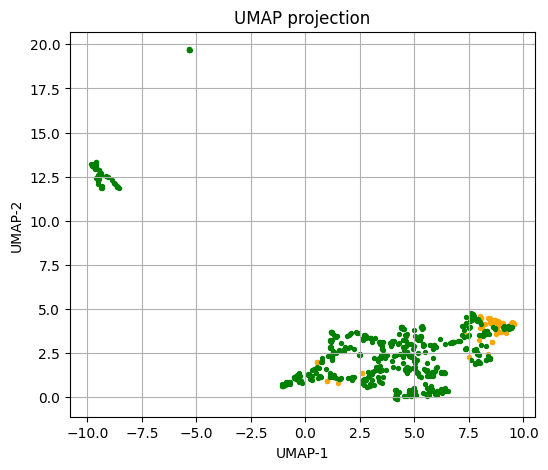

In [ ]:
import umap
# Fit UMAP to reduce to 2D
X=pca_full.values
Y=pca_part.values

# scaler = StandardScaler()
# scaled_x=X/100
# scaled_y = Y/100
reducer = umap.UMAP(n_components=2, random_state=42)
embedding_full = _u.transform(X)
embedding_part = _u.transform(Y)


#print("UMAP embedding shape:", embedding.shape)  # should be (8, 2)

# Scatter plot of the 2D embedding
plt.figure(figsize=(6,5))
plt.scatter(embedding_full[:,0], embedding_full[:,1], s=8, color='orange')

plt.scatter(embedding_part[:,0], embedding_part[:,1], s=8, color='green')

plt.title("UMAP projection")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.grid(True)
plt.show()

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (507, 2)


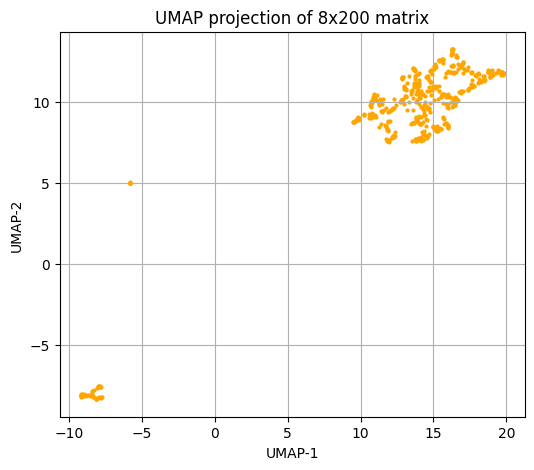

In [ ]:
# Fit UMAP to reduce to 2D
pca_part.dropna(inplace=True)   
X=pca_part.values
reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(X)


print("UMAP embedding shape:", embedding.shape)  # should be (8, 2)

# Scatter plot of the 2D embedding
plt.figure(figsize=(6,5))
plt.scatter(embedding[:,0], embedding[:,1], s=4, color='orange')

plt.title("UMAP projection of 8x200 matrix")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.grid(True)
plt.show()

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (507, 2)


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


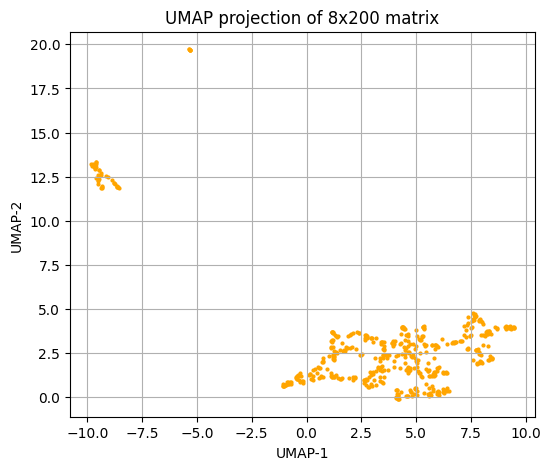

In [ ]:
pca_part.dropna(inplace=True)   
X=pca_part.values
reducer = umap.UMAP(n_components=2, random_state=42)
_u = reducer.fit(X)
embedding = _u.transform(X)



print("UMAP embedding shape:", embedding.shape)  # should be (8, 2)

# Scatter plot of the 2D embedding
plt.figure(figsize=(6,5))
plt.scatter(embedding[:,0], embedding[:,1], s=4, color='orange')

plt.title("UMAP projection of 8x200 matrix")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.grid(True)
plt.show()

In [119]:


def perform_pca(df,str):
    """Performs PCA on the given DataFrame and visualizes the results.
    Args:
        df (DataFrame): DataFrame containing the data for PCA.
        str (string): string to identify the plot
    Returns:
        dict: Dictionary containing principal components DataFrame, loadings, explained variance, and feature names
    """

    # Assuming pca_full is your DataFrame
    df.dropna(inplace=True)
    data_matrix = df.values
    feature_names = df.columns

    # 1. Standardize the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data_matrix)

    # 2. Apply PCA (reduce to 2 components for visualization)
    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(scaled_data)

    # 3. Explained variance
    explained_variance = pca.explained_variance_ratio_
    print(f"Explained variance ratio: {explained_variance}")
    print(f"Cumulative explained variance: {np.cumsum(explained_variance)}")

    # 4. Store results in a DataFrame
    principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

    # 5. Get PCA loadings (contribution of each feature to PCs)
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    loading_df = pd.DataFrame(loadings, index=feature_names, columns=['PC1', 'PC2'])

    print("\nTop contributing features to PC1:")
    print(loading_df['PC1'].abs().sort_values(ascending=False).head())

    print("\nTop contributing features to PC2:")
    print(loading_df['PC2'].abs().sort_values(ascending=False).head())

    # 6. Visualization: Scatter plot of PC1 vs PC2
    # plt.figure(figsize=(8,6))
    # plt.scatter(principal_df['PC1'], principal_df['PC2'], alpha=0.7)
    # plt.xlabel(f"PC1 ({explained_variance[0]*100:.2f}% variance)")
    # plt.ylabel(f"PC2 ({explained_variance[1]*100:.2f}% variance)")
    # plt.title("PCA - First Two Principal Components")
    # plt.grid(True)
    # plt.show()

    return {'p_df' :principal_df, 
            'load':loadings, 
            'var' : explained_variance, 
            'comm':feature_names}

    # 7. Biplot: Show feature vectors on top of scatter
    
    # plt.scatter(principal_df['PC1'], principal_df['PC2'], alpha=0.5)

    # for i, feature in enumerate(feature_names):
    #     plt.arrow(0, 0, loadings[i,0]*2, loadings[i,1]*2, 
    #             color='r', alpha=0.5, head_width=0.05)
    #     plt.text(loadings[i,0]*2.2, loadings[i,1]*2.2, feature, color='g', ha='center')

    # plt.xlabel(f"PC1 ({explained_variance[0]*100:.2f}% variance)")
    # plt.ylabel(f"PC2 ({explained_variance[1]*100:.2f}% variance)")
    # plt.title(f"PCA Biplot (PC1 vs PC2 with feature loadings) {str} ")
    # plt.grid(True)
    # plt.show()


In [120]:
def plot_PCA(principal_df, loadings, explained_variance, feature_names, str):
    """Plots PCA results with feature loadings.

    Args:
        principal_df (DataFrame): DataFrame containing principal components.
        loadings (ndarray): PCA loadings for each feature.
        explained_variance (ndarray): Explained variance ratio for each PC.
        feature_names (Index): Names of the features.
        str (string): string to identify the plot
    """
    plt.figure(figsize=(8,6))
    plt.scatter(principal_df['PC1'], principal_df['PC2'], alpha=0.5)

    for i, feature in enumerate(feature_names):
        plt.arrow(0, 0, loadings[i,0]*2, loadings[i,1]*2, 
                color='r', alpha=0.5, head_width=0.05)
        plt.text(loadings[i,0]*2.2, loadings[i,1]*2.2, feature, color='g', ha='center')

    plt.xlabel(f"PC1 ({explained_variance[0]*100:.2f}% variance)")
    plt.ylabel(f"PC2 ({explained_variance[1]*100:.2f}% variance)")
    plt.title(f"PCA Biplot (PC1 vs PC2 with feature loadings) {str} ")

In [ ]:
pca_data=perform_pca(pca_full, "bla full")

Explained variance ratio: [0.80638933 0.10308042]
Cumulative explained variance: [0.80638933 0.90946975]

Top contributing features to PC1:
orb     0.973007
mid     0.956214
mo      0.947866
vis     0.945060
hipp    0.929976
Name: PC1, dtype: float64

Top contributing features to PC2:
hind    0.724348
olf     0.376446
mid     0.262543
hth     0.201405
orb     0.199931
Name: PC2, dtype: float64


In [ ]:
pca_data=perform_pca(pca_full, "bla full")

Explained variance ratio: [0.80638933 0.10308042]
Cumulative explained variance: [0.80638933 0.90946975]

Top contributing features to PC1:
orb     0.973007
mid     0.956214
mo      0.947866
vis     0.945060
hipp    0.929976
Name: PC1, dtype: float64

Top contributing features to PC2:
hind    0.724348
olf     0.376446
mid     0.262543
hth     0.201405
orb     0.199931
Name: PC2, dtype: float64


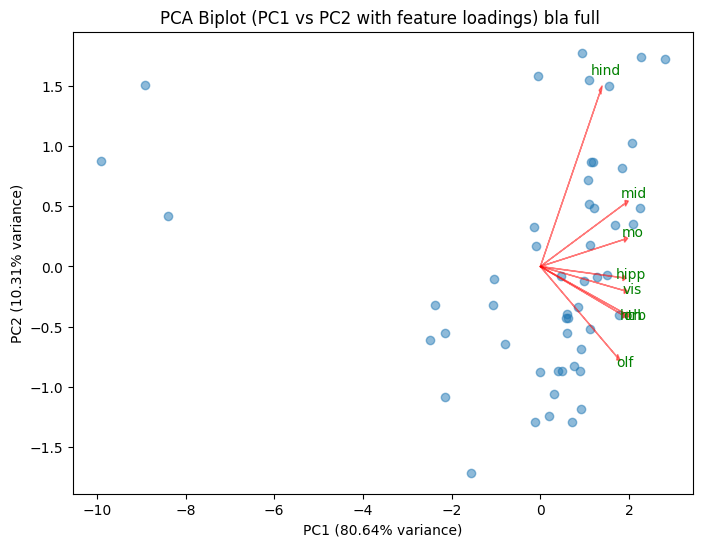

In [ ]:
plot_PCA(pca_data['p_df'], pca_data['load'], pca_data['var'], pca_data['comm'], "bla full")

In [ ]:
pca_data=perform_pca(pca_part, "bla part")

Explained variance ratio: [0.69185904 0.12839261]
Cumulative explained variance: [0.69185904 0.82025165]

Top contributing features to PC1:
orb     0.950743
mid     0.928131
hipp    0.882102
hth     0.880456
mo      0.837916
Name: PC1, dtype: float64

Top contributing features to PC2:
hind    0.626629
olf     0.470095
mo      0.367386
hth     0.334979
hipp    0.321542
Name: PC2, dtype: float64


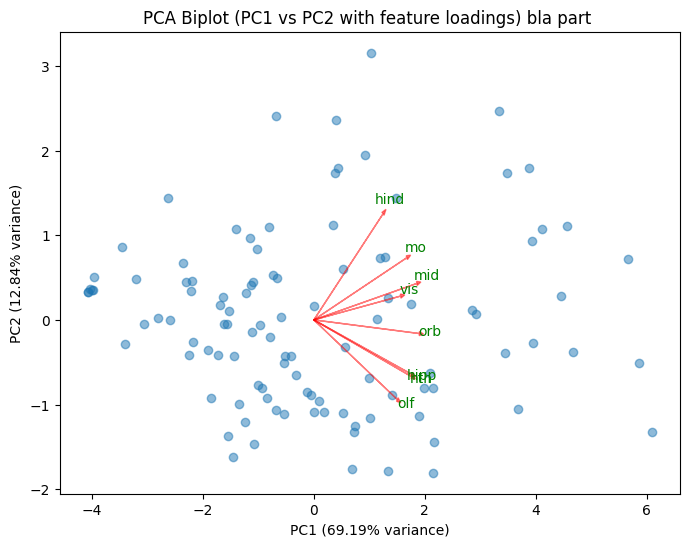

In [ ]:
plot_PCA(pca_data['p_df'], pca_data['load'], pca_data['var'], pca_data['comm'], "bla part")

In [ ]:
pca_data=perform_pca(pca_full, "fn full")

Explained variance ratio: [0.72018375 0.11660476]
Cumulative explained variance: [0.72018375 0.83678852]

Top contributing features to PC1:
orb    0.962261
mid    0.933371
mo     0.887853
hth    0.887001
vis    0.883280
Name: PC1, dtype: float64

Top contributing features to PC2:
hind    0.779958
olf     0.333386
hth     0.264385
mid     0.245435
mo      0.182587
Name: PC2, dtype: float64


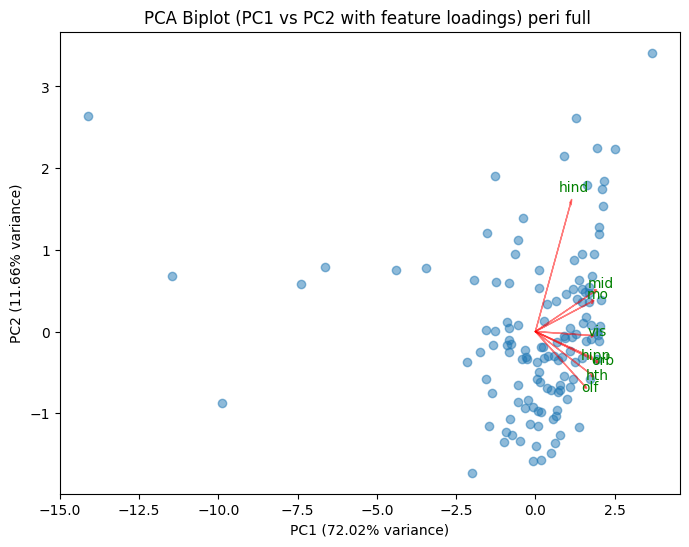

In [ ]:
plot_PCA(pca_data['p_df'], pca_data['load'], pca_data['var'], pca_data['comm'], "peri full")
  

In [ ]:
pca_part_data=perform_pca(pca_part, "full part")

Explained variance ratio: [0.69185904 0.12839261]
Cumulative explained variance: [0.69185904 0.82025165]

Top contributing features to PC1:
orb     0.947739
mid     0.925199
hipp    0.879315
hth     0.877674
mo      0.835269
Name: PC1, dtype: float64

Top contributing features to PC2:
hind    0.624650
olf     0.468610
mo      0.366225
hth     0.333921
hipp    0.320526
Name: PC2, dtype: float64


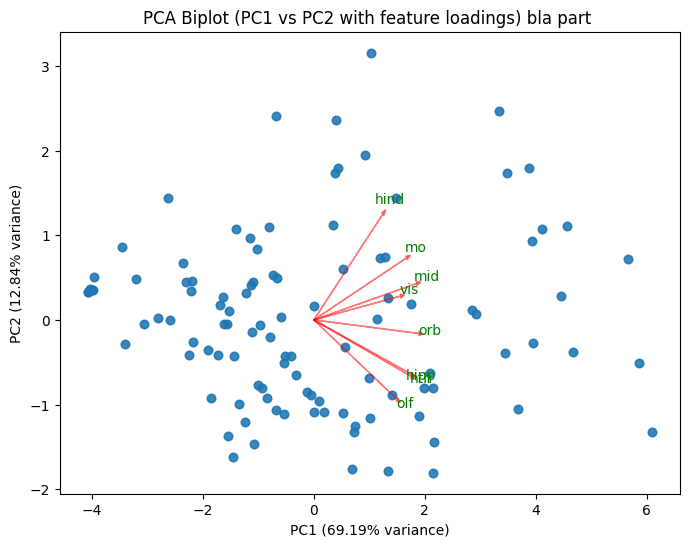

In [ ]:
plot_PCA(pca_part_data['p_df'], pca_part_data['load'], pca_part_data['var'], pca_part_data['comm'], "bla part")

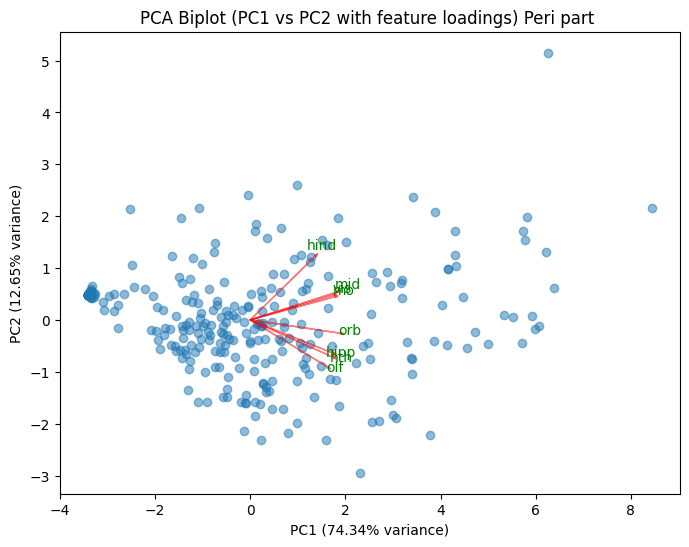

In [ ]:
plot_PCA(pca_part_data['p_df'], pca_part_data['load'], pca_part_data['var'], pca_part_data['comm'], "Peri part")

# Automate PCA for all data

In [ ]:
folder_path=Path('../../data/raw/workstation/')
files_go=glob.glob(str(folder_path/'tes_*_go.bz2'))
files_nc=glob.glob(str(folder_path/'tes_*_nc.bz2'))

print(files_go)
print(files_nc) 

['..\\..\\data\\raw\\workstation\\tes_bla_go.bz2', '..\\..\\data\\raw\\workstation\\tes_enti_go.bz2', '..\\..\\data\\raw\\workstation\\tes_fn_go.bz2', '..\\..\\data\\raw\\workstation\\tes_lha_go.bz2', '..\\..\\data\\raw\\workstation\\tes_lsc_go.bz2', '..\\..\\data\\raw\\workstation\\tes_mob_go.bz2', '..\\..\\data\\raw\\workstation\\tes_mop_go.bz2', '..\\..\\data\\raw\\workstation\\tes_mos_go.bz2', '..\\..\\data\\raw\\workstation\\tes_mrn_go.bz2', '..\\..\\data\\raw\\workstation\\tes_orb_go.bz2', '..\\..\\data\\raw\\workstation\\tes_peri_go.bz2', '..\\..\\data\\raw\\workstation\\tes_pir_go.bz2', '..\\..\\data\\raw\\workstation\\tes_re_go.bz2']
['..\\..\\data\\raw\\workstation\\tes_bla_nc.bz2', '..\\..\\data\\raw\\workstation\\tes_enti_nc.bz2', '..\\..\\data\\raw\\workstation\\tes_fn_nc.bz2', '..\\..\\data\\raw\\workstation\\tes_lha_nc.bz2', '..\\..\\data\\raw\\workstation\\tes_lsc_nc.bz2', '..\\..\\data\\raw\\workstation\\tes_mob_nc.bz2', '..\\..\\data\\raw\\workstation\\tes_mop_nc.bz2'

In [ ]:
files_nc[0:1][0].split('_')[-2]

'bla'

In [ ]:
data_folder=Path('../../data/raw/workstation/pca_results/')


for f_go, f_nc in zip(files_go, files_nc):
    print(f'Processing files: {f_go} and {f_nc}')
    df_go=pd.read_pickle(f_go, compression="bz2")
    df_nc=pd.read_pickle(f_nc, compression="bz2")
    get_avg_comm_particptn(df_go,df_nc)

    pca_full=pd.DataFrame({
    'mo':comm_partcptn.full_mo_per,
    'vis':comm_partcptn.full_vis_per,
    'orb':comm_partcptn.full_orb_per,
    'hth':comm_partcptn.full_hth_per,
    'olf':comm_partcptn.full_olf_per,
    'hipp':comm_partcptn.full_hipp_per,
    'mid':comm_partcptn.full_mid_per,
    'hind':comm_partcptn.full_hind_per
    })
    
    pca_full.to_pickle(data_folder/f'pca_full_df_{f_go.split("_")[-2]}', compression="bz2")
  

    #plot_PCA(pca_data['p_df'], pca_data['load'], pca_data['var'], pca_data['comm'], f_go.split('_')[-2] + " full")

    pca_part=pd.DataFrame({
    'mo':comm_partcptn.part_mo_per,
    'vis':comm_partcptn.part_vis_per,
    'orb':comm_partcptn.part_orb_per,
    'hth':comm_partcptn.part_hth_per,
    'olf':comm_partcptn.part_olf_per,
    'hipp':comm_partcptn.part_hipp_per,
    'mid':comm_partcptn.part_mid_per,
    'hind':comm_partcptn.part_hind_per
    })
    
    pca_part.to_pickle(data_folder/f'pca_part_df_{f_go.split("_")[-2]}', compression="bz2")

Processing files: ..\..\data\raw\workstation\tes_bla_go.bz2 and ..\..\data\raw\workstation\tes_bla_nc.bz2


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

0


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


1


...

58


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


59


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
pca_part=reader.data_read_bz2('raw\workstation\pca_results\pca_part_df_bla')
pca_full=reader.data_read_bz2('raw\workstation\pca_results\pca_full_df_bla')

In [ ]:
pca_data=reader.data_read_bz2('raw/workstation/pca_results/pca_full_df_bla')

In [ ]:
pca_data

,mo,vis,orb,hth,olf,hipp,mid,hind
0,68.000088,68.289409,76.014199,77.723354,80.547003,77.044335,64.737861,9.906633
1,72.338393,78.908000,81.452941,82.945455,82.798611,73.111000,70.641429,6.076163
2,65.899107,80.475000,87.427941,81.610227,95.141667,70.178000,58.357857,2.979651
3,75.963115,80.703825,81.567020,75.212370,82.797511,70.273224,65.167057,6.758165
4,72.008929,85.525000,84.723529,81.417045,86.568056,80.521000,70.727857,4.923837
...,...,...,...,...,...,...,...,...
303,61.954726,66.314607,71.309436,75.934327,78.424029,66.230007,46.704749,2.405509
304,64.273214,80.964000,84.463235,73.793182,93.288889,58.669000,61.473571,3.175000
305,74.602679,82.586000,81.182353,78.760227,82.477778,79.058000,63.982143,5.274419
306,75.961607,78.339000,85.745588,74.037500,94.061111,71.204000,53.148571,4.136047


In [ ]:
with open(data_folder/f'pca_full_{f_go.split("_")[-2]}', "wb") as f:
        pickle.dump(pca_data, f)

In [ ]:
with open(data_folder/f'pca_part_{f_go.split("_")[-2]}', "wb") as f:
        pickle.dump(pca_part_data, f)

In [ ]:
pd.DataFrame(pca_data)

ValueError: Per-column arrays must each be 1-dimensional

### PCA in Full Network

In [ ]:

perform_pca_and_visualize(pca_full, "FN full")



Explained variance ratio: [0.77584133 0.11233071]
Cumulative explained variance: [0.77584133 0.88817203]

Top contributing features to PC1:
orb     0.972094
mid     0.961095
mo      0.958543
hth     0.933356
hipp    0.932438
Name: PC1, dtype: float64

Top contributing features to PC2:
hind    0.697732
olf     0.478954
hth     0.274986
mid     0.258276
orb     0.172911
Name: PC2, dtype: float64


{'p_df':           PC1       PC2
 0   -0.843482 -1.518735
 1    0.438092 -0.655187
 2   -1.774912  0.503416
 3   -0.804153  0.046201
 4    0.313142 -0.499340
 5   -0.698086 -0.116514
 6    0.843355 -0.150281
 7    0.588482 -0.854535
 8    1.601337  1.640626
 9   -0.456102 -0.980957
 10   2.057415  1.585981
 11   0.627718 -1.155690
 12  -0.300054 -0.448346
 13   1.310368  0.508549
 14   1.890518  0.999704
 15   1.555188  0.229986
 16   0.094015 -0.627814
 17   1.989871  1.576298
 18 -11.822342  2.409220
 19   1.134845 -0.392415
 20  -0.662374 -1.151132
 21   1.382086  0.129233
 22   0.408562 -0.733575
 23  -0.344156 -0.978733
 24   0.736204 -0.705665
 25   1.904977  2.014126
 26  -0.116316  1.294478
 27   1.477438  0.134806
 28   0.209908 -1.009047
 29   1.285460 -0.291833
 30  -0.809146 -0.293451
 31   0.805538 -0.148962
 32   1.569259  0.403805
 33   0.382081 -1.389688
 34  -8.487778 -1.202964
 35   0.289085  0.218604
 36   0.106702  0.392136
 37   1.460015  0.446975
 38   1.131846  0

In [ ]:
perform_pca_and_visualize(pca_full, "FN part")

Explained variance ratio: [0.77584133 0.11233071]
Cumulative explained variance: [0.77584133 0.88817203]

Top contributing features to PC1:
orb     0.972094
mid     0.961095
mo      0.958543
hth     0.933356
hipp    0.932438
Name: PC1, dtype: float64

Top contributing features to PC2:
hind    0.697732
olf     0.478954
hth     0.274986
mid     0.258276
orb     0.172911
Name: PC2, dtype: float64


{'p_df':           PC1       PC2
 0   -0.843482 -1.518735
 1    0.438092 -0.655187
 2   -1.774912  0.503416
 3   -0.804153  0.046201
 4    0.313142 -0.499340
 5   -0.698086 -0.116514
 6    0.843355 -0.150281
 7    0.588482 -0.854535
 8    1.601337  1.640626
 9   -0.456102 -0.980957
 10   2.057415  1.585981
 11   0.627718 -1.155690
 12  -0.300054 -0.448346
 13   1.310368  0.508549
 14   1.890518  0.999704
 15   1.555188  0.229986
 16   0.094015 -0.627814
 17   1.989871  1.576298
 18 -11.822342  2.409220
 19   1.134845 -0.392415
 20  -0.662374 -1.151132
 21   1.382086  0.129233
 22   0.408562 -0.733575
 23  -0.344156 -0.978733
 24   0.736204 -0.705665
 25   1.904977  2.014126
 26  -0.116316  1.294478
 27   1.477438  0.134806
 28   0.209908 -1.009047
 29   1.285460 -0.291833
 30  -0.809146 -0.293451
 31   0.805538 -0.148962
 32   1.569259  0.403805
 33   0.382081 -1.389688
 34  -8.487778 -1.202964
 35   0.289085  0.218604
 36   0.106702  0.392136
 37   1.460015  0.446975
 38   1.131846  0

### PCA in PERI

In [ ]:
avg_comm_per=comm_partcptn.compute_community_participation()

In [ ]:
avg_comm_per

{'avg_full': {'MO': 67.93234999682655,
  'VIS': 75.72515045034129,
  'ORB': 79.62211602198131,
  'HTh': 72.14293516774433,
  'OLF': 84.6062991684281,
  'HIPP': 67.24306312855931,
  'MID': 58.639513481389166,
  'HIND': 4.752570594484317},
 'avg_part': {'MO': 28.564244204610766,
  'VIS': 27.822276456161124,
  'ORB': 39.42787616562893,
  'HTh': 28.74286486266817,
  'OLF': 55.15296252891246,
  'HIPP': 23.499450277277724,
  'MID': 16.995510741599254,
  'HIND': 1.3120713939917399}}

StopIteration: 

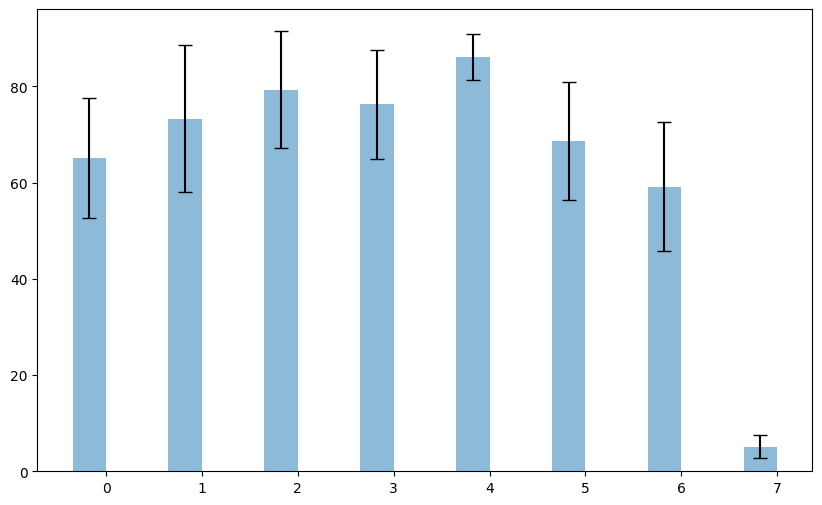

In [ ]:


# Convert dict keys and values to lists for easy plotting
keys_full = list(avg_comm_per['avg_full'].keys())
vals_full = list(avg_comm_per['avg_full'].values())
std_full = list(avg_comm_per['std_full'].values())

keys_part = list(avg_comm_per['avg_part'].keys())
vals_part = list(avg_comm_per['avg_part'].values())
std_part = list(avg_comm_per['std_part'].values())

# Ensure keys match order (assuming same keys in both dicts)
x = np.arange(len(keys_full))
width = 0.35

plt.figure(figsize=(10,6))

# Full transitions with error bars
plt.bar(x - width/2,
        vals_full,
        width=width,
        yerr=std_full,
        capsize=5,
        alpha=0.5,
        label='Full Transitions')

# Partial transitions with error bars
plt.bar(x + width/2,
        vals_part,
        width=width,
        yerr=std_part,
        capsize=5,
        alpha=0.5,
        color='orange',
        label='Partial Transitions')

# Labels and title
plt.xticks(x, keys_full, rotation=45)
plt.title('Average percentage Community Participation in Full and Partial Transitions FN')
plt.ylabel('Average % Participation')
plt.legend()
plt.tight_layout()
plt.show()


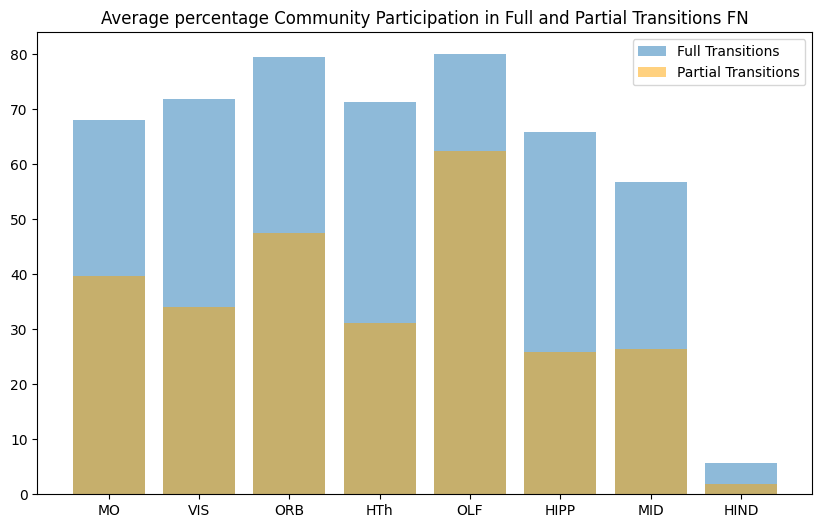

In [ ]:
#names=reader.get_communities()['name_seq']
# fig,(ax1,ax2)=plt.subplots(1,2, figsize=(12,6))
# ax1.bar(avg_comm_per['avg_full'].keys(), avg_comm_per['avg_full'].values())
# ax2.bar(avg_comm_per['avg_part'].keys(), avg_comm_per['avg_part'].values())

plt.figure(figsize=(10,6))
plt.bar(avg_comm_per['avg_full'].keys(), avg_comm_per['avg_full'].values(),alpha=0.5, label='Full Transitions')
plt.bar(avg_comm_per['avg_part'].keys(), avg_comm_per['avg_part'].values(),alpha=0.5, label='Partial Transitions',color='orange')
plt.title('Average percentage Community Participation in Full and Partial Transitions FN')
plt.legend()
plt.show()

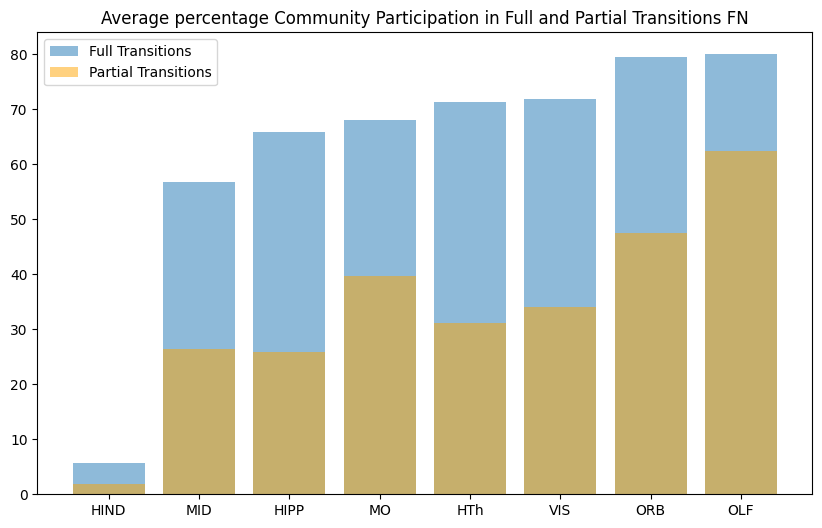

In [ ]:
import matplotlib.pyplot as plt

# Sort 'Full Transitions' by value
full_sorted = dict(sorted(avg_comm_per['avg_full'].items(), key=lambda x: x[1]))

# Reorder 'Partial Transitions' to match the order of 'Full Transitions' keys
part_sorted = {k: avg_comm_per['avg_part'].get(k, 0) for k in full_sorted.keys()}

plt.figure(figsize=(10,6))
plt.bar(full_sorted.keys(), full_sorted.values(), alpha=0.5, label='Full Transitions')
plt.bar(part_sorted.keys(), part_sorted.values(), alpha=0.5, label='Partial Transitions', color='orange')

plt.title('Average percentage Community Participation in Full and Partial Transitions FN')
plt.legend()
plt.show()



#### 

In [116]:
df_peri_nc=reader.data_read_bz2("raw/workstation/tes_peri_nc.bz2")
df_peri=reader.data_read_bz2("raw/workstation/tes_peri_go.bz2")

In [118]:

get_avg_comm_particptn(df_peri,df_peri_nc)

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

0


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


1


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

full: [80.54700328407225, 82.79861111111111, 95.14166666666667, 82.79751062537947, 86.56805555555556, 81.37638888888888, 93.36805555555556, 82.17783414359191, 89.72222222222223, 89.71527777777779, 92.64305555555555, 84.28611111111111, 92.20694444444445, 83.56666666666666, 23.677777777777777, 82.16388888888889, 87.80138888888888, 93.22500000000001, 89.62222222222222, 79.15972222222221, 87.8625, 89.6375, 83.04861111111111, 87.37083333333334, 87.30138888888888, 85.29722222222222, 91.75972222222222, 87.29027777777777, 91.19583333333333, 72.14583333333333, 83.92500000000001, 83.43055555555556, 50.221462920779544, 90.73472222222222, 85.6, 84.84305555555555, 85.45694444444445, 81.57916666666667, 81.22083333333333, 87.31805555555555, 83.69027777777778, 41.77148846960168, 83.45555555555556, 84.55555555555556, 90.23333333333333, 74.55833333333334, 84.98333333333333, 78.42402878754498, 93.28888888888889, 82.47777777777779, 94.0611111111111, 86.75, 80.54700328407225, 82.79861111111111, 95.14166666

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


full: [80.54700328407225, 82.79861111111111, 95.14166666666667, 82.79751062537947, 86.56805555555556, 81.37638888888888, 93.36805555555556, 82.17783414359191, 89.72222222222223, 89.71527777777779, 92.64305555555555, 84.28611111111111, 92.20694444444445, 83.56666666666666, 23.677777777777777, 82.16388888888889, 87.80138888888888, 93.22500000000001, 89.62222222222222, 79.15972222222221, 87.8625, 89.6375, 83.04861111111111, 87.37083333333334, 87.30138888888888, 85.29722222222222, 91.75972222222222, 87.29027777777777, 91.19583333333333, 72.14583333333333, 83.92500000000001, 83.43055555555556, 50.221462920779544, 90.73472222222222, 85.6, 84.84305555555555, 85.45694444444445, 81.57916666666667, 81.22083333333333, 87.31805555555555, 83.69027777777778, 41.77148846960168, 83.45555555555556, 84.55555555555556, 90.23333333333333, 74.55833333333334, 84.98333333333333, 78.42402878754498, 93.28888888888889, 82.47777777777779, 94.0611111111111, 86.75, 80.54700328407225, 82.79861111111111, 95.14166666

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


full: [80.54700328407225, 82.79861111111111, 95.14166666666667, 82.79751062537947, 86.56805555555556, 81.37638888888888, 93.36805555555556, 82.17783414359191, 89.72222222222223, 89.71527777777779, 92.64305555555555, 84.28611111111111, 92.20694444444445, 83.56666666666666, 23.677777777777777, 82.16388888888889, 87.80138888888888, 93.22500000000001, 89.62222222222222, 79.15972222222221, 87.8625, 89.6375, 83.04861111111111, 87.37083333333334, 87.30138888888888, 85.29722222222222, 91.75972222222222, 87.29027777777777, 91.19583333333333, 72.14583333333333, 83.92500000000001, 83.43055555555556, 50.221462920779544, 90.73472222222222, 85.6, 84.84305555555555, 85.45694444444445, 81.57916666666667, 81.22083333333333, 87.31805555555555, 83.69027777777778, 41.77148846960168, 83.45555555555556, 84.55555555555556, 90.23333333333333, 74.55833333333334, 84.98333333333333, 78.42402878754498, 93.28888888888889, 82.47777777777779, 94.0611111111111, 86.75, 80.54700328407225, 82.79861111111111, 95.14166666

In [121]:
avg_comm_per=comm_partcptn.compute_community_participation()

In [122]:
avg_comm_per

{'avg_full': {'MO': 67.2063212959143,
  'VIS': 74.0662557391864,
  'ORB': 79.04498924097908,
  'HTh': 72.32073787502921,
  'OLF': 85.08017561443832,
  'HIPP': 66.20857418469738,
  'MID': 57.224534447221565,
  'HIND': 4.700253969594924},
 'avg_part': {'MO': nan,
  'VIS': nan,
  'ORB': nan,
  'HTh': nan,
  'OLF': nan,
  'HIPP': nan,
  'MID': nan,
  'HIND': nan}}

In [ ]:
reader.get_communities()

In [ ]:
def scatter_plot(avg_dict, ax):
    fig,(a)


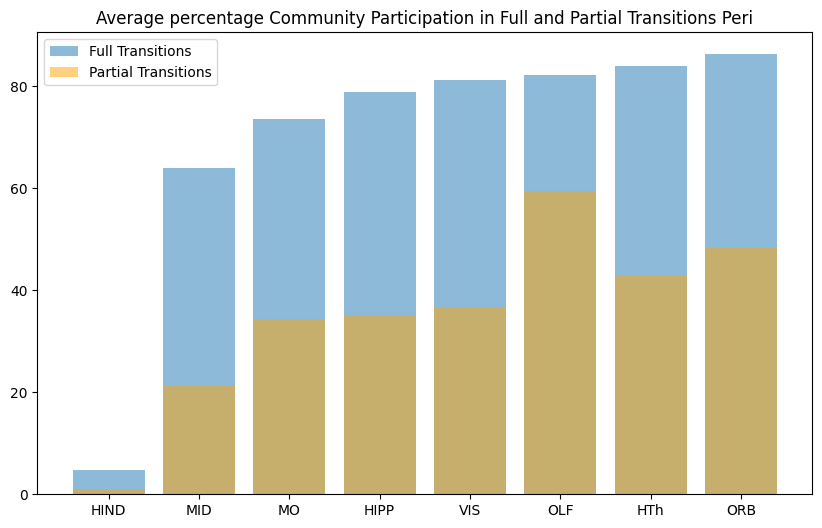

In [ ]:
import matplotlib.pyplot as plt

# Sort 'Full Transitions' by value
full_sorted = dict(sorted(avg_comm_per['avg_full'].items(), key=lambda x: x[1]))

# Reorder 'Partial Transitions' to match the order of 'Full Transitions' keys
part_sorted = {k: avg_comm_per['avg_part'].get(k, 0) for k in full_sorted.keys()}

plt.figure(figsize=(10,6))
plt.bar(full_sorted.keys(), full_sorted.values(), alpha=0.5, label='Full Transitions')
plt.bar(part_sorted.keys(), part_sorted.values(), alpha=0.5, label='Partial Transitions', color='orange')

plt.title('Average percentage Community Participation in Full and Partial Transitions Peri')
plt.legend()
plt.show()



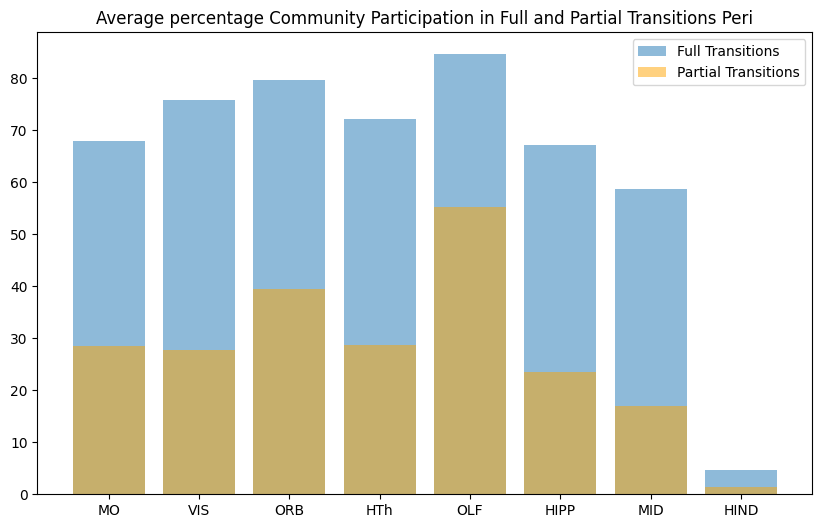

In [ ]:
plt.figure(figsize=(10,6))
plt.bar(avg_comm_per['avg_full'].keys(), avg_comm_per['avg_full'].values(),alpha=0.5, label='Full Transitions')
plt.bar(avg_comm_per['avg_part'].keys(), avg_comm_per['avg_part'].values(),alpha=0.5, label='Partial Transitions',color='orange')
plt.title('Average percentage Community Participation in Full and Partial Transitions Peri')
plt.legend()
plt.show()

{'HIND': 4.752570594484317, 'MID': 58.639513481389166, 'HIPP': 67.24306312855931, 'MO': 67.93234999682655, 'HTh': 72.14293516774433, 'VIS': 75.72515045034129, 'ORB': 79.62211602198131, 'OLF': 84.6062991684281}
{'HIND': 1.3120713939917399, 'MID': 16.995510741599254, 'HIPP': 23.499450277277724, 'MO': 28.564244204610766, 'HTh': 28.74286486266817, 'VIS': 27.822276456161124, 'ORB': 39.42787616562893, 'OLF': 55.15296252891246}


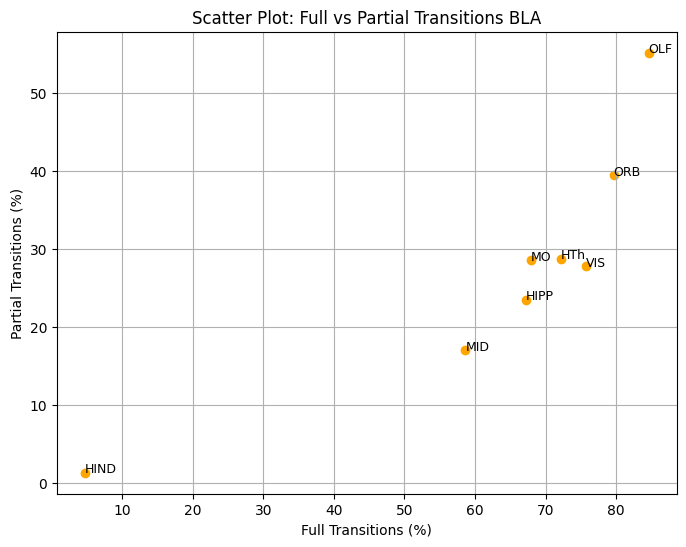

In [ ]:
import matplotlib.pyplot as plt

# Sort 'Full Transitions' by value
full_sorted = dict(sorted(avg_comm_per['avg_full'].items(), key=lambda x: x[1]))

# Reorder 'Partial Transitions' to match the order of 'Full Transitions' keys
part_sorted = {k: avg_comm_per['avg_part'].get(k, 0) for k in full_sorted.keys()}
print(full_sorted)
print(part_sorted)
# Create scatter plot
plt.figure(figsize=(8,6))
plt.scatter(full_sorted.values(), part_sorted.values(), color='orange')

# Add labels for each point (optional)
for k, x, y in zip(full_sorted.keys(), full_sorted.values(), part_sorted.values()):
    plt.text(x, y, k, fontsize=9)

plt.xlabel('Full Transitions (%)')
plt.ylabel('Partial Transitions (%)')
plt.title('Scatter Plot: Full vs Partial Transitions BLA')
plt.grid(True)
plt.show()



In [ ]:
# full network
param_fn=algo.compute_param_df(df_fn)

In [ ]:
param_fn[0]

{'n_part': 20,
 'n_full': 10,
 'n_total': 30,
 'itr_tran': [0,
  1,
  2,
  5,
  6,
  7,
  8,
  10,
  11,
  12,
  13,
  14,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24]}

In [ ]:
param_peri = algo.compute_param_df(df_peri)

In [ ]:
param_peri[0]

{'n_part': 18,
 'n_full': 5,
 'n_total': 23,
 'itr_tran': [4, 5, 6, 10, 11, 12, 13, 14, 15, 17, 19, 21, 22, 23, 24]}

In [ ]:
pts=algoumap.compute_parameters(df_peri[5])
# algoumap.plot_transition()

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
algoumap.plot_transition(df_peri[5],pts['start_points'],pts['stop_points'])

In [ ]:
df_loc_peri.loc[5].iloc[0:426]

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
0,0.167406,0.176834,0.186374,0.195959,0.205529,0.215028,0.224408,0.233623,0.242636,0.251413,...,0.472650,0.470164,0.467538,0.464771,0.461860,0.458803,0.455593,0.452228,0.448702,0.445009
1,0.105868,0.109681,0.113445,0.117153,0.120795,0.124365,0.127856,0.131263,0.134582,0.137809,...,0.175068,0.171374,0.167580,0.163687,0.159696,0.155610,0.151431,0.147161,0.142804,0.138365
2,0.116790,0.121040,0.125228,0.129341,0.133367,0.137294,0.141110,0.144806,0.148372,0.151799,...,0.258484,0.255481,0.252405,0.249259,0.246047,0.242771,0.239437,0.236049,0.232612,0.229132
3,0.290160,0.297788,0.305172,0.312307,0.319187,0.325805,0.332153,0.338223,0.344005,0.349492,...,0.184771,0.177926,0.170925,0.163785,0.156525,0.149169,0.141741,0.134276,0.126811,0.119395
4,0.065031,0.069161,0.073223,0.077214,0.081130,0.084967,0.088722,0.092390,0.095969,0.099454,...,0.218597,0.211916,0.205196,0.198448,0.191678,0.184895,0.178110,0.171331,0.164569,0.157836
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421,0.166991,0.176487,0.186035,0.195595,0.205130,0.214611,0.224013,0.233314,0.242493,0.251534,...,0.360159,0.357768,0.355030,0.351970,0.348617,0.344997,0.341140,0.337075,0.332832,0.328443
422,0.219830,0.225141,0.230379,0.235518,0.240534,0.245405,0.250109,0.254630,0.258950,0.263057,...,0.097852,0.095687,0.093505,0.091306,0.089094,0.086871,0.084638,0.082398,0.080153,0.077907
423,0.127429,0.128883,0.130336,0.131787,0.133236,0.134683,0.136127,0.137566,0.138999,0.140425,...,0.118697,0.115352,0.112288,0.109552,0.107192,0.105249,0.103761,0.102755,0.102253,0.102262
424,0.198280,0.206980,0.215491,0.223796,0.231882,0.239735,0.247342,0.254692,0.261775,0.268582,...,0.142422,0.136249,0.129825,0.123165,0.116281,0.109189,0.101909,0.094460,0.086870,0.079171


In [ ]:
fig,((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2)

ax1.plot(analyse.smooth(df_peri[5].iloc[pts['start_points'][0]-3000:pts['start_points'][0]+2000])) 
ax3.imshow(df_loc_peri.loc[5].iloc[0:426],aspect='auto',cmap='Reds')

ax2.plot(analyse.smooth(df_peri[5].iloc[pts['start_points'][1]-3000:pts['start_points'][1]+2000])) 
ax4.imshow(df_loc_peri.loc[5].iloc[426:852],aspect='auto',cmap='Reds')

In [ ]:
## node community extraction
reader.ext_node_community(df_loc_fn,0.5,"raw/workstation/tes_fn_nc.bz2")

#### Checking node community data

In [ ]:
df_fn_nc = reader.data_read_bz2('raw/workstation/tes_fn_nc.bz2')
df_peri_nc = reader.data_read_bz2('raw/workstation/tes_peri_nc.bz2')

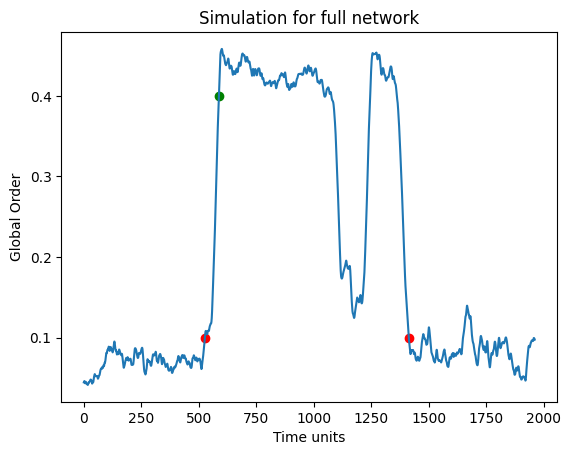

In [ ]:
n=10
analyse.plot_global_synchrony(df_peri[n],0.05)

In [ ]:
df_peri_nc.loc[n].shape


(10000, 426)

1


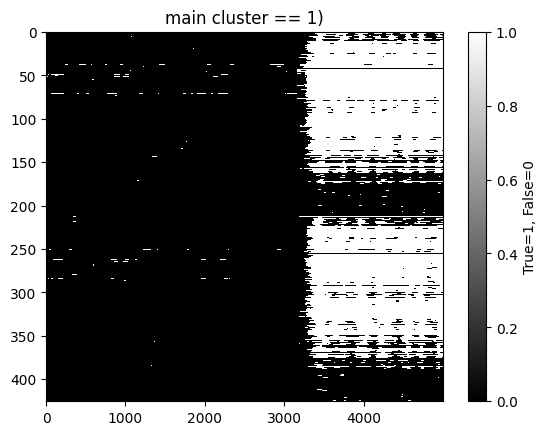

In [ ]:

nc_array = df_peri_nc.loc[n].iloc[0:5000].values
nc=nc_array.copy()
mc = analyse.compute_main_cluster(df_peri_nc.loc[n].iloc[0:5000])
print(mc)

binary_mask = np.isclose(nc, mc)

# Visualize binary mask
plt.imshow(binary_mask.T, cmap='gray', interpolation='nearest', aspect = 'auto')
plt.title(f"main cluster == {mc})")
plt.colorbar(label='True=1, False=0')
plt.show()

In [ ]:
bm=binary_mask.T
id=bm[:,3999]
s_r=bm[id,:]

In [ ]:
row_numbers = np.where(bm[:, 3999])[0]

In [ ]:
row_numbers

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  74,  75,  76,  77,  78,  79,
        80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,
        93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105,
       106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118,
       119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131,
       132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 144, 145,
       146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 158, 159,
       160, 161, 162, 166, 167, 168, 173, 174, 190, 213, 214, 215, 216,
       217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 22

In [ ]:
#Map rows to community

comm_dict=reader.get_communities()

In [ ]:
l_communities=reader.data_read_pkl("connectivity_matrix/mb_communities_dict.pickle")

In [ ]:
community_names = {
        0: "MO",
        1: "MID",
        2: "VIS",
        3: "ORB",
        4: "HTh",
        5: "HIND",
        6: "OLF",
        7: "HIPP",
    }
communities = {community_names[i]: v for i, v in l_communities.items()}

In [ ]:
df_comm_map=comm_dict['comm_map']

In [ ]:
comm_dict['comm_val']

MO      56
VIS     50
ORB     34
HTh     44
OLF     36
HIPP    50
MID     70
HIND    86
dtype: int64

In [ ]:
df_comm_map.index

Int64Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
            ...
            416, 417, 418, 419, 420, 421, 422, 423, 424, 425],
           dtype='int64', length=426)

In [ ]:
mo_c=0
vis_c=0
orb_c=0
hth_c=0
olf_c=0
hipp_c=0
mid_c=0
hind_c=0


for element in  row_numbers:
    if element in communities['MO']:
        mo_c+=1
    elif element in communities['VIS']:
        vis_c+=1
    elif element in communities['ORB']:
        orb_c+=1
    elif element in communities['HTh']:
        hth_c+=1
    elif element in communities['OLF']:
        olf_c+=1    
    elif element in communities['HIPP']:
        hipp_c+=1
    elif element in communities['MID']:
        mid_c+=1    
    elif element in communities['HIND']:
        hind_c+=1   
        
comm_name = comm_dict['comm_val'].index.tolist()
comm_count=dict(zip(comm_name,[mo_c,vis_c,orb_c,hth_c,olf_c,hipp_c,mid_c,hind_c]))
per_comm={}
for name, total in comm_dict['comm_val'].items():
    print(f'{name} {(comm_count[name]/total)*100}%')
    per_comm[f'{name}']=(comm_count[name]/total)*100



MO 100.0%
VIS 100.0%
ORB 100.0%
HTh 97.72727272727273%
OLF 94.44444444444444%
HIPP 100.0%
MID 85.71428571428571%
HIND 4.651162790697675%


In [ ]:
per_comm

{'MO': 100.0,
 'VIS': 100.0,
 'ORB': 100.0,
 'HTh': 97.72727272727273,
 'OLF': 94.44444444444444,
 'HIPP': 100.0,
 'MID': 85.71428571428571,
 'HIND': 4.651162790697675}

In [ ]:
mc = analyse.compute_main_cluster(df_fn_nc.loc[n])

In [ ]:
n=2
df_fn_nc.loc[2].shape

(10000, 426)

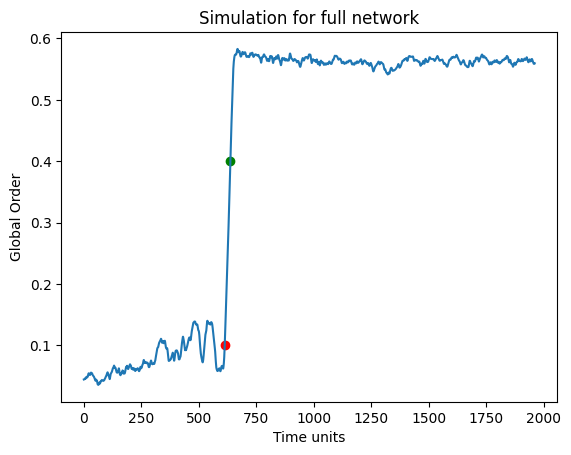

In [ ]:
n=1
analyse.plot_global_synchrony(df_fn[n],0.05)

In [ ]:
n=10
mc=analyse.compute_main_cluster(df_peri_nc.loc[n].iloc[0:5000])
nc=df_peri_nc.loc[n].iloc[0:5000].values
get_node(nc, mc)

{'MO': 82.14285714285714,
 'VIS': 100.0,
 'ORB': 100.0,
 'HTh': 100.0,
 'OLF': 91.66666666666666,
 'HIPP': 92.0,
 'MID': 74.28571428571429,
 'HIND': 3.488372093023256}

In [ ]:
def get_node(nc_array,mc):
    nc=nc_array.copy()
    
    binary_mask = np.isclose(nc, mc)
    bm=binary_mask.T
    row_numbers = np.where(bm[:, 3999])[0]

    mo_c=0
    vis_c=0
    orb_c=0
    hth_c=0
    olf_c=0
    hipp_c=0
    mid_c=0
    hind_c=0


    for element in  row_numbers:
        if element in communities['MO']:
            mo_c+=1
        elif element in communities['VIS']:
            vis_c+=1
        elif element in communities['ORB']:
            orb_c+=1
        elif element in communities['HTh']:
            hth_c+=1
        elif element in communities['OLF']:
            olf_c+=1    
        elif element in communities['HIPP']:
            hipp_c+=1
        elif element in communities['MID']:
            mid_c+=1    
        elif element in communities['HIND']:
            hind_c+=1   
            
    
   
    
    comm_name = comm_dict['comm_val'].index.tolist()
    comm_count=dict(zip(comm_name,[mo_c,vis_c,orb_c,hth_c,olf_c,hipp_c,mid_c,hind_c]))
    per_comm={}
    for name, total in comm_dict['comm_val'].items():
        #print(f'{name} {(comm_count[name]/total)*100}%')
        per_comm[f'{name}']=(comm_count[name]/total)*100
        
    return per_comm
    

In [ ]:
get_node(nc, mc)

MO 100.0%
VIS 100.0%
ORB 100.0%
HTh 97.72727272727273%
OLF 94.44444444444444%
HIPP 100.0%
MID 85.71428571428571%
HIND 4.651162790697675%


{'MO': 100.0,
 'VIS': 100.0,
 'ORB': 100.0,
 'HTh': 97.72727272727273,
 'OLF': 94.44444444444444,
 'HIPP': 100.0,
 'MID': 85.71428571428571,
 'HIND': 4.651162790697675}

In [ ]:
comm_count

{'MO': 56,
 'VIS': 50,
 'ORB': 34,
 'HTh': 43,
 'OLF': 34,
 'HIPP': 50,
 'MID': 60,
 'HIND': 4}

In [ ]:
comm_dict['comm_val'].index.tolist()

['MO', 'VIS', 'ORB', 'HTh', 'OLF', 'HIPP', 'MID', 'HIND']